In [102]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [103]:
import torch
from torchvision.transforms import v2
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib import cm
import os, sys
import pandas as pd

import plotly.graph_objects as go

from box import Box
import yaml

root_dir = os.path.abspath('../..')

if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.data_loader.utils import img_polar2cart
from src.data_loader.transforms import SpeckleNoise, RayArtifacts
from src.data_loader.evaluation_data_generator import DataGenerator


In [109]:
def visu_polar_and_carth(i_polars, row_titles=None, r_min=0.2, r_max=100.0, fov=135 * np.pi / 180, cmap = 'inferno'):
    if not isinstance(i_polars, list):
        i_polars = [i_polars]

    n = len(i_polars)

    if row_titles is not None:
        if not isinstance(row_titles, list):
            row_titles = [row_titles]
        if len(row_titles) < n:
            row_titles.extend([""] * (n - len(row_titles)))
    
    first_cart = img_polar2cart(i_polars[0], r_min, r_max, fov, out_shape=None, bg=0)
    W_pol = i_polars[0].shape[1]
    W_cart = first_cart.shape[1]

    fig, ax = plt.subplots(
        n, 2, 
        figsize=(15, 5 * n),
        squeeze=False,
        gridspec_kw={
            'width_ratios': [W_pol, W_cart],
            'wspace': 0.05,
            'hspace': 0.01
        }
    )

    for idx, i_polar in enumerate(i_polars):
        i_cart = img_polar2cart(i_polar, r_min, r_max, fov, out_shape=None, bg=0)

        # Tytuł dla całego wiersza
        if row_titles and row_titles[idx]:
            ax[idx, 0].text(-0.25, 0.5, row_titles[idx], transform=ax[idx, 0].transAxes,
                            rotation=90, va='center', ha='right', fontsize=12, fontweight='bold')

        # === Układ polarny ===
        ax[idx, 0].imshow(i_polar[:, :], cmap=cmap)
        ax[idx, 0].axis('off')

        # === Układ kartezjański ===
        ax[idx, 1].imshow(i_cart[:, :], cmap=cmap)
        ax[idx, 1].axis('off')
       

    plt.tight_layout(w_pad=0.05)
    plt.show()



def visu_single(imgs, row_titles=None, cmap='inferno'):
    if not isinstance(imgs, list):
        imgs = [imgs]

    n = len(imgs)

    if row_titles is not None:
        if not isinstance(row_titles, list):
            row_titles = [row_titles]
        if len(row_titles) < n:
            row_titles.extend([""] * (n - len(row_titles)))

    fig, ax = plt.subplots(
        n, 1,
        figsize=(7, 5 * n),
        squeeze=False
    )

    for idx, img in enumerate(imgs):
        if row_titles and row_titles[idx]:
            ax[idx, 0].text(
                -0.15, 0.5,
                row_titles[idx],
                transform=ax[idx, 0].transAxes,
                rotation=90,
                va='center',
                ha='right',
                fontsize=12,
                fontweight='bold'
            )

        ax[idx, 0].imshow(img, cmap=cmap)
        ax[idx, 0].axis('off')

    plt.tight_layout()
    plt.show()

In [105]:
root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry'
data_root_dir =  os.path.join(root_dir, 'SonarOdometryDataset/test_scenarios/seq_3')
model_config_pth = os.path.join(root_dir, 'config/model2d.yaml')
sonar_config_pth = os.path.join(root_dir, 'config/sonar.yaml')
aracati_pth = os.path.join(root_dir, 'data/aracati2017/fls/4000.png')
image_num = 15

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(model_config_pth, "r") as f:
            model_config = Box(yaml.safe_load(f))

with open(sonar_config_pth, "r") as f:
            sonar_config = Box(yaml.safe_load(f))

from src.models.utils import ExtrinsicsCalib
extrinsics_calib = ExtrinsicsCalib(T = [sonar_config.position.x, sonar_config.position.y, sonar_config.position.z],
                                   R = [sonar_config.position.roll, sonar_config.position.pitch, sonar_config.position.yaw])


# from src.data_loader.transforms import SonarDatasetTranforms

fls_resolution = (model_config.input.polar_height, model_config.input.polar_width)

m = 7.250794635405014
transform = v2.Compose([
    RayArtifacts(0.0, 0.03, 0, 10, num_rays=4, probability=1.0),
    v2.GaussianBlur(kernel_size=(7, 5), sigma=(1.0, 2.0)),
    SpeckleNoise(concentration=m, rate=m)])

data_generator = DataGenerator(data_root_dir, device, fls_resolution=fls_resolution, transforms = transform, calibration = extrinsics_calib)

r_min = sonar_config.range.min
r_max = sonar_config.range.min
fov = sonar_config.fov.horizontal

C:\Users\janis\AppData\Local\Temp\ipykernel_22368\2617684402.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=0.05)


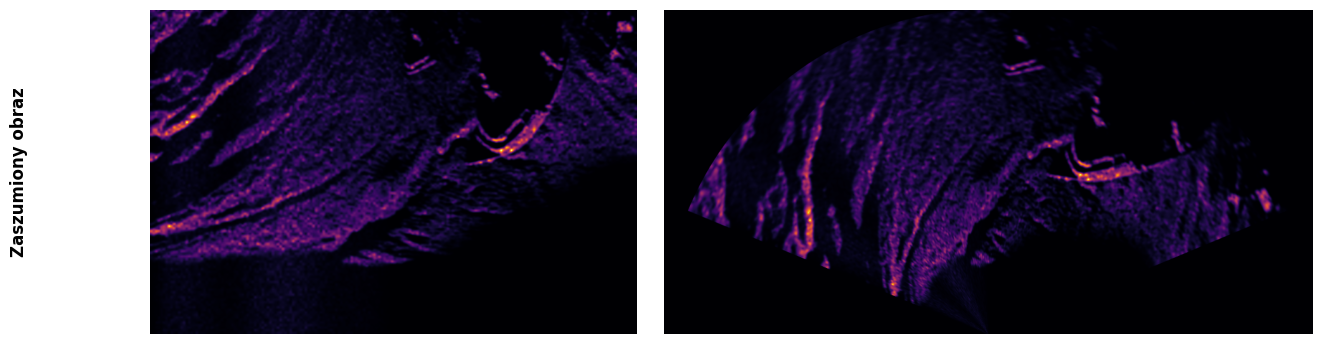

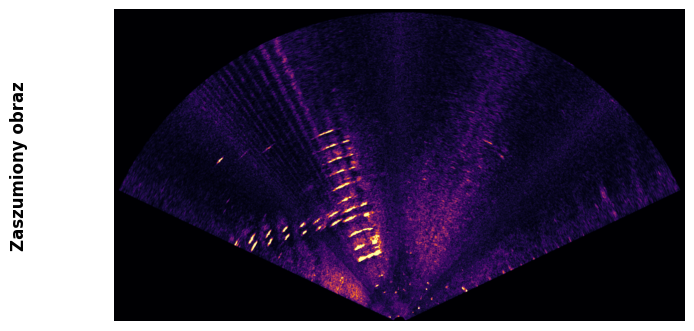

In [120]:
t, frame_noise, pose_gt, depth= data_generator.get_sample(image_num, return_visu=False, return_depth=True)
# frame_noise_visu = frame_noise.squeeze().unsqueeze(-1).detach().cpu().numpy()
frame_np_norm = frame_noise.squeeze().detach().cpu().numpy()
frame_np = np.clip(frame_np_norm * 255.0, 0, 255).astype(np.uint8)
visu_polar_and_carth(frame_np[..., np.newaxis], row_titles='Zaszumiony obraz', r_min=0.2, r_max=100.0, fov=135 * np.pi / 180, cmap = 'inferno')


aracati_np = cv2.imread(aracati_pth, 0)
visu_single(aracati_np[..., np.newaxis], row_titles='Zaszumiony obraz')

Filtr Medianowy

C:\Users\janis\AppData\Local\Temp\ipykernel_22368\2617684402.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=0.05)


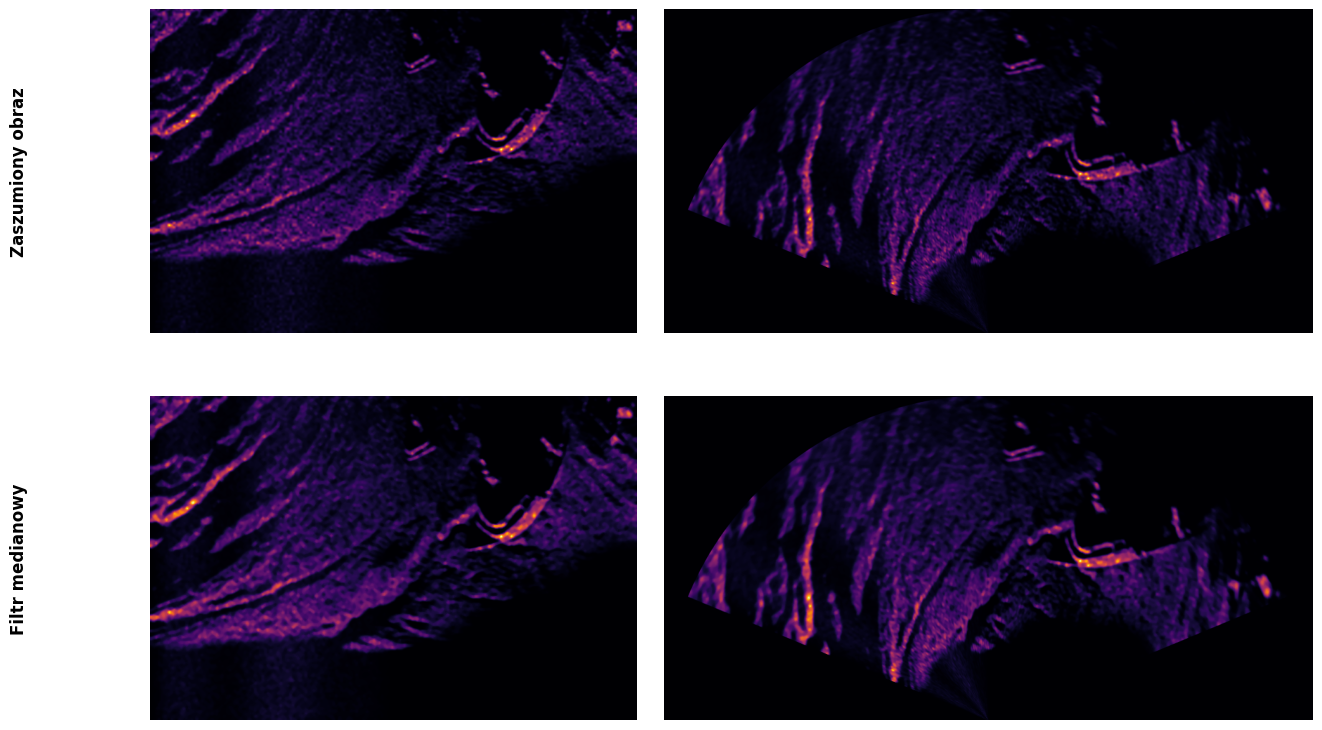

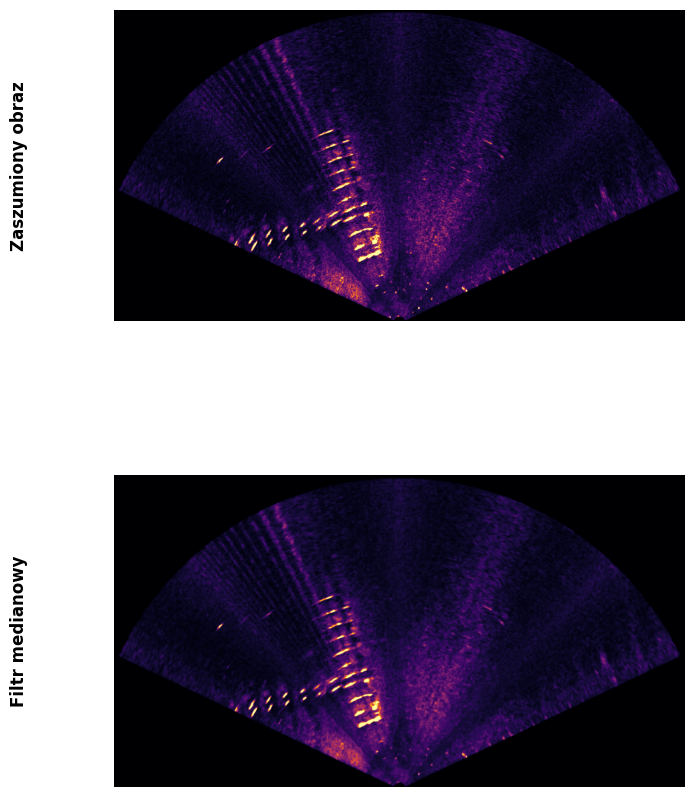

In [121]:
frame_blured = cv2.medianBlur(frame_np, ksize=5)
aracti_blured = cv2.medianBlur(aracati_np, ksize=5)

visu_polar_and_carth([frame_np[..., np.newaxis],
      frame_blured[..., np.newaxis]],
      row_titles=['Zaszumiony obraz',
                  'Filtr medianowy'],
                  r_min=0.2, r_max=100.0, fov=135 * np.pi / 180, cmap = 'inferno')

visu_single([aracati_np[..., np.newaxis],
             aracti_blured[..., np.newaxis]],
             row_titles=['Zaszumiony obraz',
                         'Filtr medianowy'])                 

C:\Users\janis\AppData\Local\Temp\ipykernel_22368\2617684402.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=0.05)


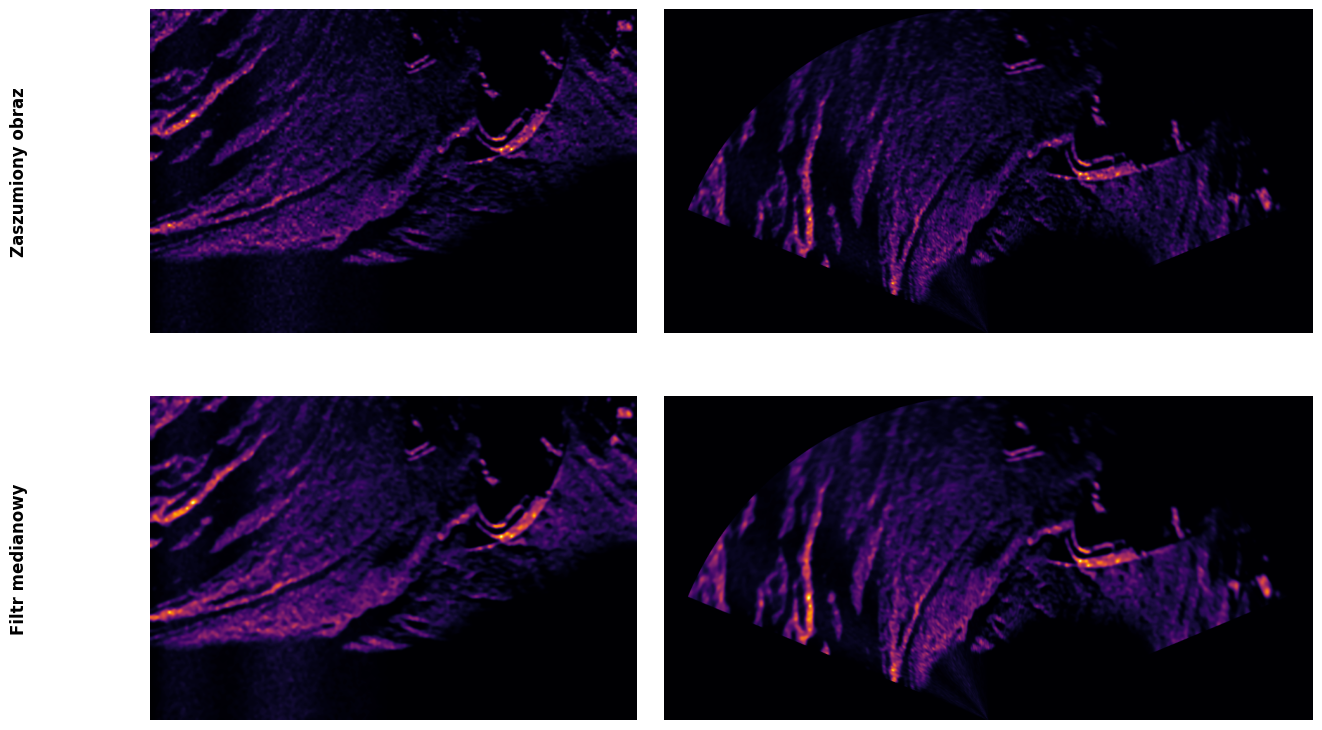

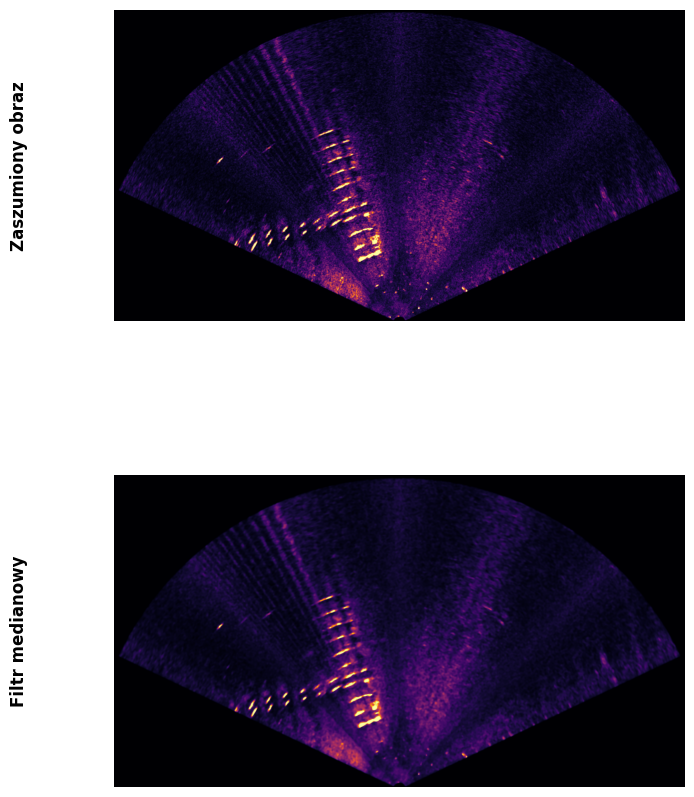

In [125]:
frame_bilatelar = cv2.bilateralFilter(frame_blured, d=5, sigmaColor=50, sigmaSpace=7)
aracati_bilatelar = cv2.bilateralFilter(aracti_blured, d=5, sigmaColor=50, sigmaSpace=7)

visu_polar_and_carth([frame_np[..., np.newaxis],
      frame_bilatelar[..., np.newaxis]],
      row_titles=['Zaszumiony obraz',
                  'Filtr medianowy'],
                  r_min=0.2, r_max=100.0, fov=135 * np.pi / 180, cmap = 'inferno')


visu_single([aracati_np[..., np.newaxis],
             aracati_bilatelar[..., np.newaxis]],
             row_titles=['Zaszumiony obraz',
                         'Filtr medianowy'])               

C:\Users\janis\AppData\Local\Temp\ipykernel_22368\2617684402.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=0.05)


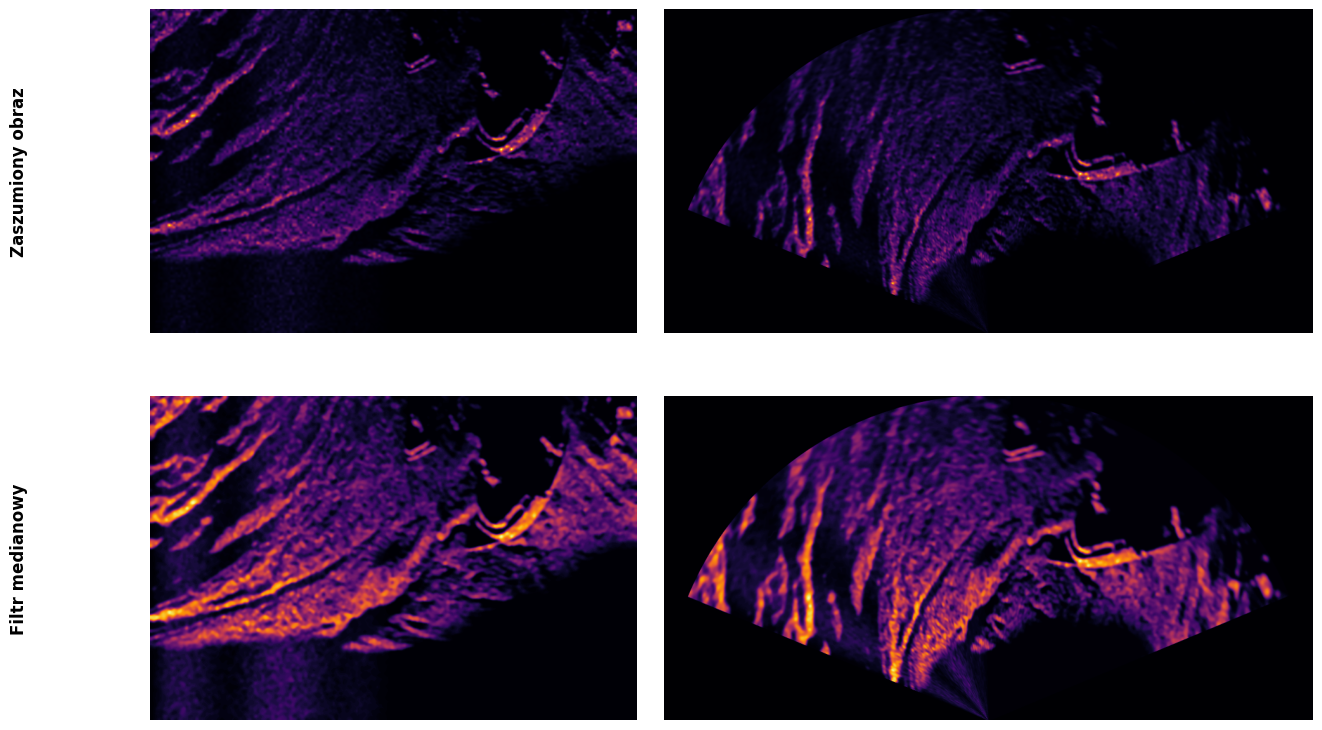

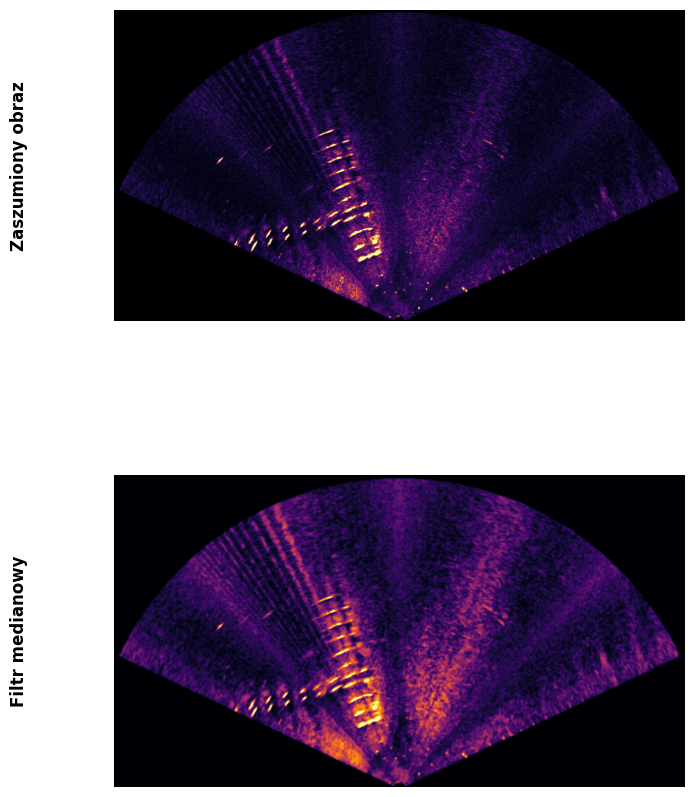

In [126]:
clahe = cv2.createCLAHE(clipLimit=2, tileGridSize=(8, 8))
filtered = clahe.apply(frame_bilatelar)

clahe = cv2.createCLAHE(clipLimit=2, tileGridSize=(8, 8))
aracati_filtered = clahe.apply(aracati_bilatelar)

visu_polar_and_carth([frame_np[..., np.newaxis],
      filtered[..., np.newaxis]],
      row_titles=['Zaszumiony obraz',
                  'Filtr medianowy'],
                  r_min=0.2, r_max=100.0, fov=135 * np.pi / 180, cmap = 'inferno')

visu_single([aracati_np[..., np.newaxis],
             aracati_filtered[..., np.newaxis]],
             row_titles=['Zaszumiony obraz',
                         'Filtr medianowy'])               

C:\Users\janis\AppData\Local\Temp\ipykernel_22368\2617684402.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=0.05)


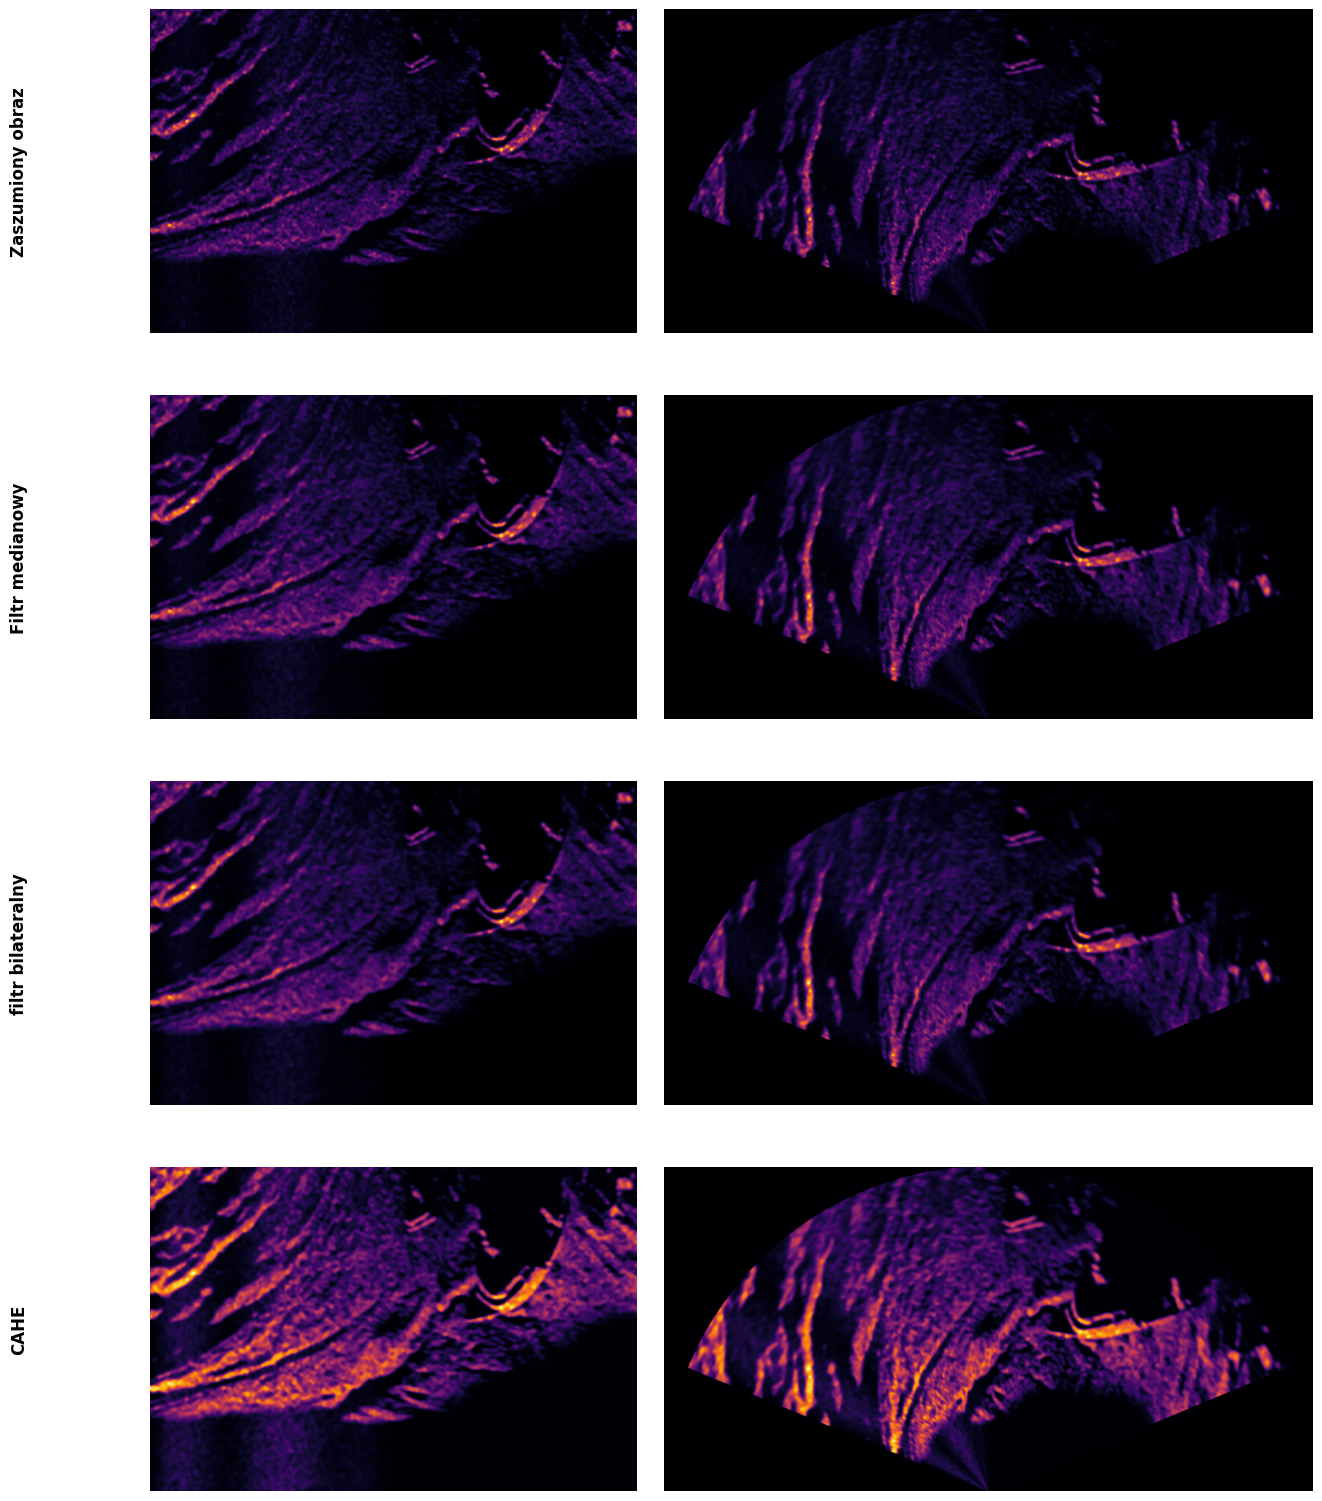

In [127]:
# get together 

visu_polar_and_carth([frame_np[..., np.newaxis],
                      frame_blured[..., np.newaxis],
                      frame_bilatelar[..., np.newaxis],
                      filtered[..., np.newaxis]],

      row_titles=['Zaszumiony obraz',
                  'Filtr medianowy',
                  'filtr bilateralny',
                  'CAHE'],
                  r_min=0.2, r_max=100.0, fov=135 * np.pi / 180, cmap = 'inferno')

In [ ]:
def fls_filter(self, frame):
       device = frame.device 
       b, c, h, w = frame.shape
       # norm torch tensor -> np array
       frame_np = frame.squeeze().detach().cpu().numpy()
       frame_uint8 = np.clip(frame_np * 255.0, 0, 255).astype(np.uint8)
       # median blur
       blured = cv2.medianBlur(frame_uint8, ksize=3)
       # bilateral filter
       bilateral = cv2.bilateralFilter(blured, d=5, sigmaColor=25, sigmaSpace=5)
       # histogram equalization - CLAHE
       clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
       filtered = clahe.apply(bilateral)
       # np array -> norm torch tensor
       filtered_float = filtered.astype(np.float32) / 255.0
       frame_torch = torch.tensor(filtered_float, device=device).unsqueeze(0)
       return frame_torch